# Ames Housing: reproducible, leakage-safe regression pipeline

## 1. Problem definition

Predict `SalePrice` for Ames homes. This notebook reconstructs the useful ideas from the
original exploratory notebook — quality encodings and category consolidation — without
spreadsheet dependencies or any transformation applied before the data split.

**Protocol:** split the raw data once into 80% development / 20% untouched test data. EDA,
preprocessing, cross-validation, and tuning use development data only; the test data are
touched exactly once, for the final audit. Every non-baseline model family is tuned with a
randomized hyperparameter search over the same development folds, so the final `model.pkl`
is chosen from genuinely competitive configurations rather than one favored model.

### Reproducibility

Required packages: pandas, numpy, matplotlib, seaborn, scipy, scikit-learn, joblib. Raw
input: `sources/AmesHousing.csv` (falls back to `data/AmesHousing.csv` or `AmesHousing.csv`).

The feature-engineering transformer and its mapping tables live in **`ames_features.py`**, a
plain module kept next to this notebook. That keeps the notebook itself short and, more
importantly, lets `model.pkl` be unpickled in a fresh Python process: joblib needs to import
the class that defines each pipeline step, and a class defined inline in a notebook lives in
`__main__`, which doesn't exist outside that kernel. Fixed random seeds make the workflow
repeatable.

In [4]:
from pathlib import Path
from time import perf_counter
import platform
import kagglehub 
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from scipy.stats import loguniform, randint, uniform
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor, make_column_selector
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from ames_features import AmesFeatureEngineer, CATEGORY_COLLAPSE

%matplotlib inline
RANDOM_STATE = 42
TARGET = "SalePrice"
TEST_SIZE = 0.20
N_SEARCH_ITER = 8
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
print(f"Python {platform.python_version()} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")

Python 3.14.4 | pandas 3.0.5 | scikit-learn 1.9.0


## 2. Dataset loading and initial inspection

The checks below document the input without fitting a transformer or making target-driven
decisions. Subsequent EDA and all feature decisions are restricted to the development data.

In [ ]:
candidates = [Path("sources/AmesHousing.csv"), Path("data/AmesHousing.csv"), Path("AmesHousing.csv")]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    print("AmesHousing.csv was not found in sources/, data/, or the notebook directory.\n Tryig to download from Kaggle...")
    kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset",output_dir="./data",force_download=True)
    DATA_PATH = Path("data/AmesHousing.csv")
raw = pd.read_csv(DATA_PATH)
if TARGET not in raw:
    raise ValueError(f"Expected target {TARGET!r} was not found.")
if raw[TARGET].isna().any():
    raise ValueError("Target contains missing values; define a target policy before modeling.")

audit = pd.Series({
    "Rows": len(raw),
    "Columns": raw.shape[1],
    "Numeric columns": raw.select_dtypes(include=np.number).shape[1],
    "Categorical columns": raw.select_dtypes(exclude=np.number).shape[1],
    "Exact duplicate rows": int(raw.duplicated().sum()),
    "Missing targets": int(raw[TARGET].isna().sum()),
}, name="value")
display(audit.to_frame())
display(raw.head(3))

,value
Rows,2930
Columns,82
Numeric columns,39
Categorical columns,43
Exact duplicate rows,0
Missing targets,0


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.000,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.000,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.000,Unf,0.000,441.000,"1,080.000",GasA,Fa,Y,SBrkr,1656,0,0,1656,1.000,0.000,1,0,3,1,TA,7,Typ,2,Gd,Attchd,"1,960.000",Fin,2.000,528.000,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.000,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,CBlock,TA,TA,No,Rec,468.000,LwQ,144.000,270.000,882.000,GasA,TA,Y,SBrkr,896,0,0,896,0.000,0.000,1,0,2,1,TA,5,Typ,0,NaN,Attchd,"1,961.000",Unf,1.000,730.000,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.000,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.000,TA,TA,CBlock,TA,TA,No,ALQ,923.000,Unf,0.000,406.000,"1,329.000",GasA,TA,Y,SBrkr,1329,0,0,1329,0.000,0.000,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,"1,958.000",Unf,1.000,312.000,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000


## 3. Train/test split

`Order` and `PID` are kept in the raw source for audit but removed by the feature
transformer: they are record/parcel identifiers, not house attributes. No high-priced or
unusual homes are dropped here; a target-informed removal would need a separate, documented
business rule.

In [6]:
X_raw = raw.drop(columns=TARGET)
y = raw[TARGET].astype(float)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)
train_df = X_train.copy()
train_df[TARGET] = y_train
assert set(X_train.index).isdisjoint(X_test.index)
print(f"Development rows: {len(X_train):,} | Held-out test rows: {len(X_test):,}")

Development rows: 2,344 | Held-out test rows: 586


## 4. Exploratory data analysis

Everything below uses the development set only. The overview covers the target distribution,
strong numeric relationships, quality/area scatterplots, a neighborhood comparison, and
missingness — it motivates conservative totals and ordinal encodings, which still have to earn
their place through cross-validation.

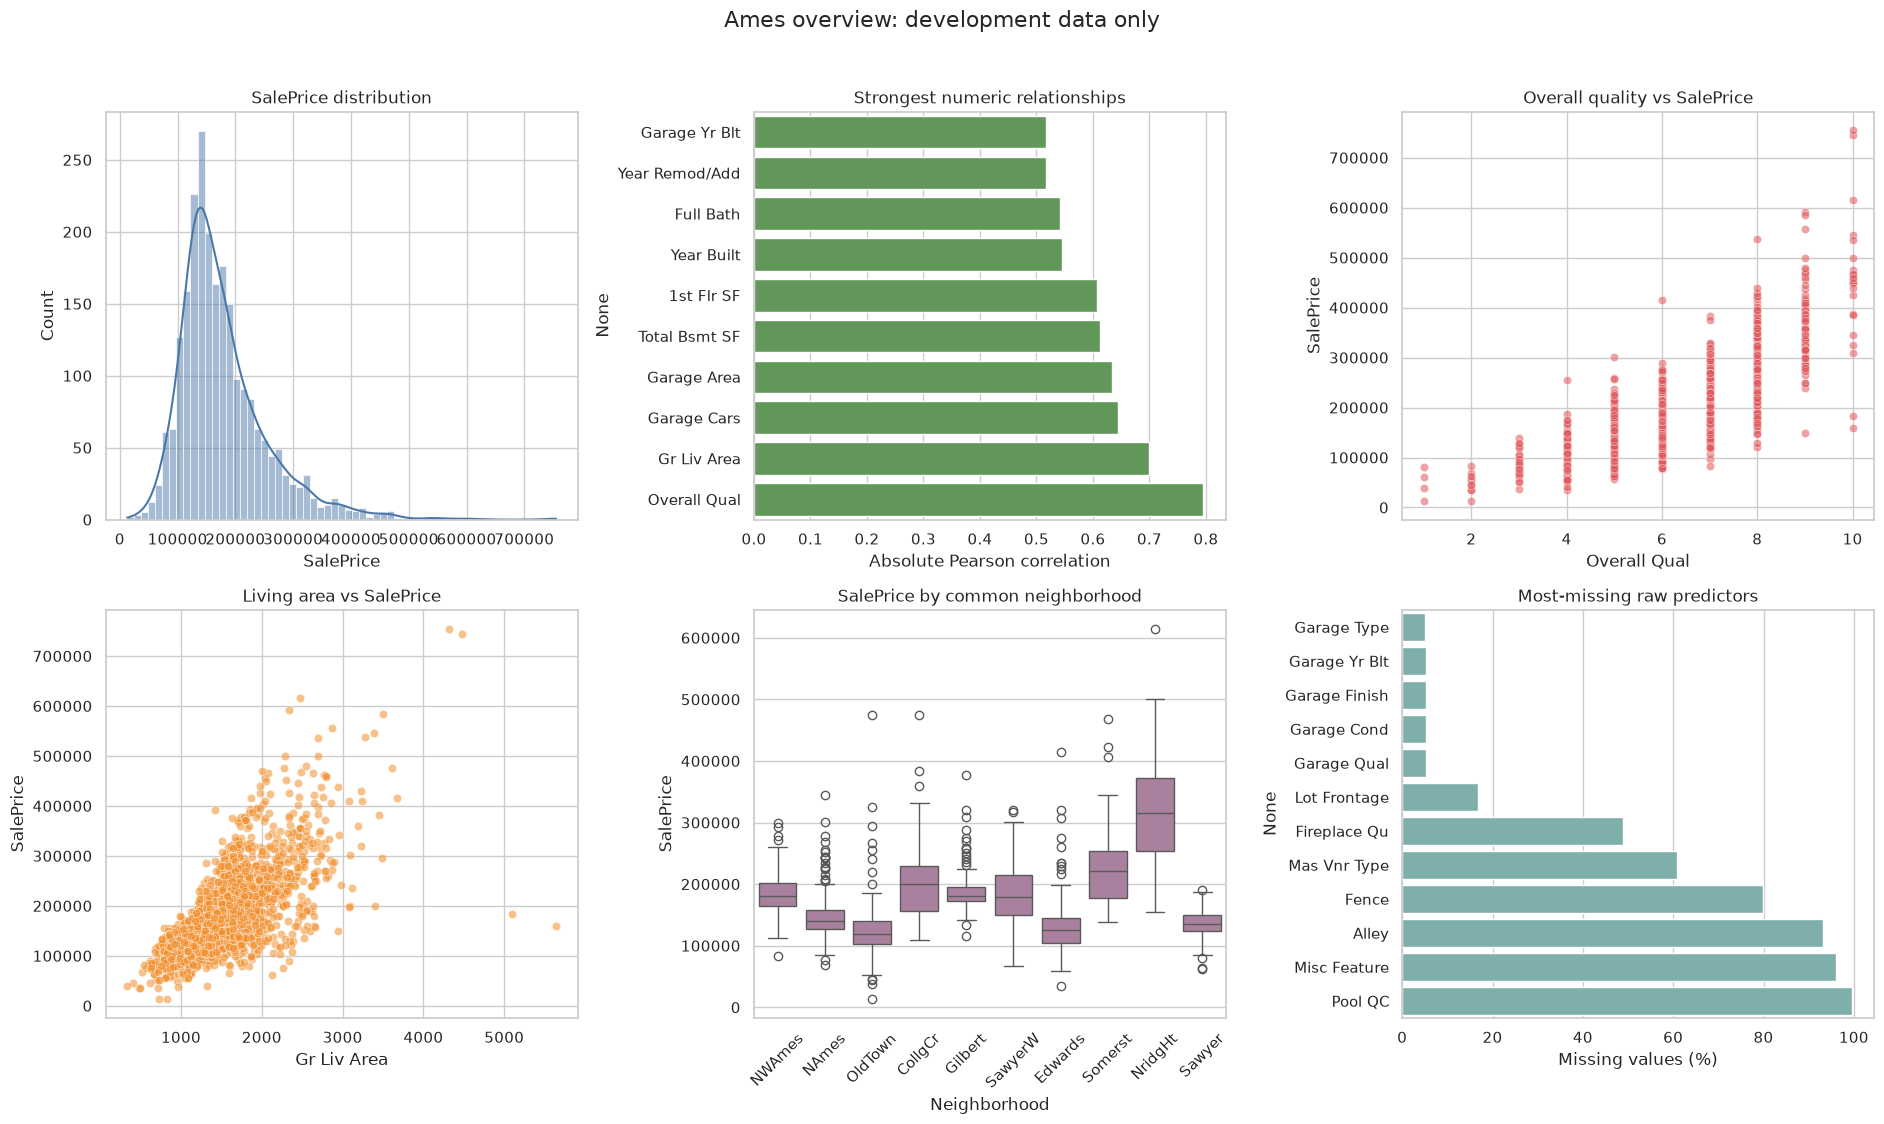

,absolute_correlation
Overall Qual,0.795
Gr Liv Area,0.698
Garage Cars,0.644
Garage Area,0.633
Total Bsmt SF,0.612
1st Flr SF,0.607
Year Built,0.545
Full Bath,0.542
Year Remod/Add,0.518
Garage Yr Blt,0.516


In [7]:
numeric_eda = train_df.select_dtypes(include=np.number).drop(columns=["Order", "PID"], errors="ignore")
correlations = numeric_eda.corr(numeric_only=True)[TARGET].drop(TARGET).abs().sort_values(ascending=False)
top_corr = correlations.head(10).sort_values()
common_neighborhoods = train_df["Neighborhood"].value_counts().head(10).index
missing = X_train.isna().mean().sort_values(ascending=False)
missing = missing[missing.gt(0)].head(12).sort_values()

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
sns.histplot(train_df[TARGET], kde=True, ax=axes[0, 0], color="#4C78A8").set_title("SalePrice distribution")
sns.barplot(x=top_corr.values, y=top_corr.index, ax=axes[0, 1], color="#59A14F").set(
    title="Strongest numeric relationships", xlabel="Absolute Pearson correlation")
sns.scatterplot(data=train_df, x="Overall Qual", y=TARGET, alpha=.55, ax=axes[0, 2], color="#E15759").set_title(
    "Overall quality vs SalePrice")
sns.scatterplot(data=train_df, x="Gr Liv Area", y=TARGET, alpha=.55, ax=axes[1, 0], color="#F28E2B").set_title(
    "Living area vs SalePrice")
sns.boxplot(data=train_df[train_df["Neighborhood"].isin(common_neighborhoods)], x="Neighborhood", y=TARGET,
            ax=axes[1, 1], color="#B07AA1").set_title("SalePrice by common neighborhood")
axes[1, 1].tick_params(axis="x", rotation=45)
if len(missing):
    sns.barplot(x=missing.values * 100, y=missing.index, ax=axes[1, 2], color="#76B7B2").set(
        title="Most-missing raw predictors", xlabel="Missing values (%)")
else:
    axes[1, 2].text(.5, .5, "No missing predictors", ha="center", va="center")
    axes[1, 2].set_axis_off()
fig.suptitle("Ames overview: development data only", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()
display(pd.DataFrame({"absolute_correlation": correlations.head(15)}))

**Interpretation.** The original focus on quality and total space is consistent with the
development-set views. Missingness can signify that an amenity is absent, so imputation
belongs inside the pipeline and selected quality variables use an absence score of zero.
Neighborhood is retained: it carries useful location information and one-hot encoding doesn't
invent a numeric order.

## 5. Reconstruction of Excel-based analysis

The original notebook showed two manual operations: ordered quality labels were scored, and
related/rare categories were consolidated. The missing Excel pivots can't be recovered
exactly, so the group-bys below are a training-only reconstruction of the likely reasoning —
count plus median and mean sale price per level. The mappings themselves are fixed, target-free
rules that live in `ames_features.py` (`CATEGORY_COLLAPSE`, `QUALITY_MAPPINGS`); they're
validated here and, more rigorously, through cross-validation later on.

In [8]:
reconstruction_log = pd.DataFrame([
    ("Quality fields", "Ex/Gd/TA/Fa/Po scores; absent becomes zero", "Natural ordered condition scale."),
    ("Paved Drive and Central Air", "N/P/Y and N/Y become ordered numeric values", "Documented ordinal or binary state."),
    ("Condition 1", "railroad labels become RR; positive labels become Pos", "Semantically related variants reduce sparsity."),
    ("Zoning, Heating, Electrical", "rare alternatives become Other", "Original code grouped low-support variants."),
    ("Lot Config, Functional", "related access or severity labels combine", "Preserves broad category with less fragmentation."),
    ("Dropped columns", "retain valid non-identifiers", "No evidence justified dropping location or other attributes."),
], columns=["Original clue", "Reproducible action", "Reconstructed rationale"])
display(reconstruction_log)


def category_profile(frame, column):
    return (frame.groupby(column, dropna=False)[TARGET]
            .agg(n="size", median_sale_price="median", mean_sale_price="mean")
            .sort_values(["n", "median_sale_price"], ascending=[False, False]))


for column in CATEGORY_COLLAPSE:
    print(f"\n{column}: original categories")
    display(category_profile(train_df, column))
print("\nExterior quality follows the expected ordered price profile:")
display(category_profile(train_df, "Exter Qual"))

,Original clue,Reproducible action,Reconstructed rationale
0,Quality fields,Ex/Gd/TA/Fa/Po scores; absent becomes zero,Natural ordered condition scale.
1,Paved Drive and Central Air,N/P/Y and N/Y become ordered numeric values,Documented ordinal or binary state.
2,Condition 1,railroad labels become RR; positive labels bec...,Semantically related variants reduce sparsity.
3,"Zoning, Heating, Electrical",rare alternatives become Other,Original code grouped low-support variants.
4,"Lot Config, Functional",related access or severity labels combine,Preserves broad category with less fragmentation.
5,Dropped columns,retain valid non-identifiers,No evidence justified dropping location or oth...



Condition 1: original categories


,n,median_sale_price,mean_sale_price
Condition 1,,,
Norm,2015,"164,500.000","181,965.400"
Feedr,132,"137,000.000","138,473.803"
Artery,73,"122,250.000","133,258.904"
RRAn,43,"170,440.000","182,913.140"
PosN,29,"206,000.000","246,564.034"
RRAe,23,"142,000.000","139,843.478"
PosA,15,"190,000.000","221,556.667"
RRNn,8,"184,000.000","189,906.250"
RRNe,6,"147,500.000","142,558.333"



MS Zoning: original categories


,n,median_sale_price,mean_sale_price
MS Zoning,,,
RL,1818,"170,720.000","188,846.200"
RM,371,"120,500.000","127,182.326"
FV,106,"205,475.000","215,747.415"
RH,24,"138,500.000","136,805.583"
C (all),22,"76,500.000","81,130.727"
A (agr),2,"47,300.000","47,300.000"
I (all),1,"57,625.000","57,625.000"


...

,n,median_sale_price,mean_sale_price
Electrical,,,
SBrkr,2144,"166,650.000","184,294.373"
FuseA,150,"121,875.000","122,180.313"
FuseF,41,"107,000.000","106,197.854"
FuseP,8,"78,500.000","90,175.000"
Mix,1,"67,000.000","67,000.000"



Functional: original categories


,n,median_sale_price,mean_sale_price
Functional,,,
Typ,2183,"162,500.000","181,024.454"
Min2,56,"144,200.000","147,127.357"
Min1,51,"144,000.000","150,814.706"
Mod,29,"128,500.000","151,746.655"
Maj1,14,"147,700.000","154,591.000"
Maj2,8,"76,552.000","90,013.000"
Sev,2,"95,750.000","95,750.000"
Sal,1,"13,100.000","13,100.000"



Exterior quality follows the expected ordered price profile:


,n,median_sale_price,mean_sale_price
Exter Qual,,,
TA,1461,"139,500.000","143,564.075"
Gd,773,"216,500.000","227,855.198"
Ex,82,"357,950.000","366,703.451"
Fa,28,"93,775.000","94,565.393"


## 6. Feature engineering

`AmesFeatureEngineer` (imported from `ames_features.py`) applies the mappings above and adds
`TotalSF`, `TotalBath`, `TotalPorchSF`, age-at-sale features, and presence flags — all
target-free. `MS SubClass` becomes categorical because it's a dwelling-type code, not a
continuous quantity. All other non-identifier raw columns are retained. This transformer is
the first step of every candidate pipeline, including inside every cross-validation fold, so
nothing here can leak.

In [9]:
preview = AmesFeatureEngineer().fit(X_train).transform(X_train.head(3))
display(preview[["MS SubClass", "TotalSF", "TotalBath", "HouseAgeAtSale", "HasGarage", "Exter Qual"]])

,MS SubClass,TotalSF,TotalBath,HouseAgeAtSale,HasGarage,Exter Qual
381,20,"2,460.000",2.000,33,1,3.000
834,60,"3,139.000",3.000,42,1,3.000
1898,90,"1,224.000",2.000,45,1,3.000


## 7. Preprocessing and the modeling estimator

Numeric fields get median imputation plus standardization; nominal fields get a `"Missing"`
label plus one-hot encoding. `ColumnTransformer` selects columns by post-feature-engineering
dtype, so ordered quality scores are treated as numeric while nominal fields stay categorical.
Every step lives inside the estimator handed to cross-validation, so there's no train/test or
fold leakage. `TransformedTargetRegressor` fits in log-price space and inverts predictions back
to dollars.

In [10]:
def make_preprocessor():
    numeric = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("numeric", numeric, make_column_selector(dtype_include=np.number)),
        ("categorical", categorical, make_column_selector(dtype_exclude=np.number)),
    ], remainder="drop", sparse_threshold=0, verbose_feature_names_out=True)


def make_estimator(model):
    pipeline = Pipeline([
        ("features", AmesFeatureEngineer()),
        ("preprocessor", make_preprocessor()),
        ("model", model),
    ])
    return TransformedTargetRegressor(
        regressor=pipeline, func=np.log1p, inverse_func=np.expm1, check_inverse=False
    )


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


SCORING = {
    "mae": "neg_mean_absolute_error",
    "rmse": make_scorer(rmse, greater_is_better=False),
    "r2": "r2",
}
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 8. Baseline and default-hyperparameter comparison

Every candidate gets identical raw inputs, feature transformer, preprocessing, five folds, and
original-dollar metrics. The baseline predicts the median. Ridge and Elastic Net test
regularized linear effects; Extra Trees and Random Forest test non-linear effects. The held-out
test data are not used here — and every non-baseline family gets its own hyperparameter search
in the next section, rather than singling one out.

,Model,CV MAE,CV RMSE,CV R2,CV R2 SD,Train R2,Mean fit time (s)
0,Extra Trees,"14,979.000","25,456.000",0.885,0.053,1.000,4.370
1,Random Forest,"15,759.000","26,537.000",0.876,0.052,0.984,4.210
2,Ridge,"16,121.000","45,916.000",0.267,1.302,0.911,0.090
3,Elastic Net,"16,251.000","46,790.000",0.227,1.382,0.896,0.170
4,Median baseline,"54,123.000","79,308.000",-0.060,0.015,-0.059,0.090


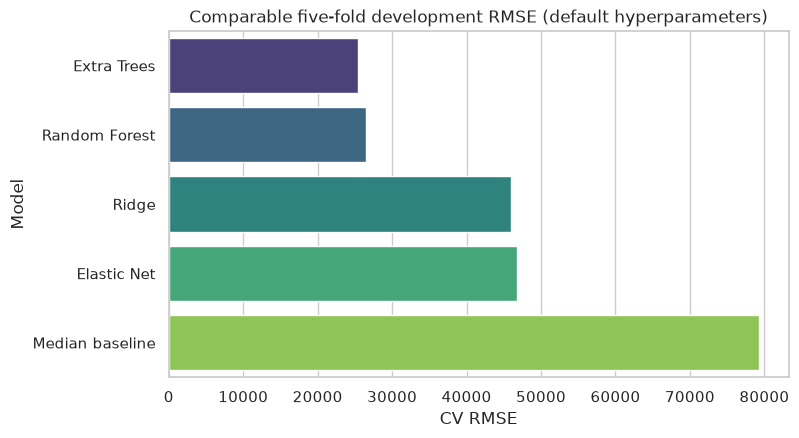

Extra Trees: CV RMSE 25,456; high train-to-CV gap; a hyperparameter search may help.
Random Forest: CV RMSE 26,537; high train-to-CV gap; a hyperparameter search may help.
Ridge: CV RMSE 45,916; high train-to-CV gap; a hyperparameter search may help.
Elastic Net: CV RMSE 46,790; high train-to-CV gap; a hyperparameter search may help.
Median baseline: CV RMSE 79,308; reference point; it ignores all property information.


In [11]:
def cv_summary(name, estimator):
    scores = cross_validate(estimator, X_train, y_train, cv=CV, scoring=SCORING,
                             return_train_score=True, n_jobs=-1, error_score="raise")
    return {
        "Model": name,
        "CV MAE": -scores["test_mae"].mean(),
        "CV RMSE": -scores["test_rmse"].mean(),
        "CV R2": scores["test_r2"].mean(),
        "CV R2 SD": scores["test_r2"].std(),
        "Train R2": scores["train_r2"].mean(),
        "Mean fit time (s)": scores["fit_time"].mean(),
    }


baseline_specs = {
    "Median baseline": DummyRegressor(strategy="median"),
    "Ridge": Ridge(alpha=20.0),
    "Elastic Net": ElasticNet(alpha=.002, l1_ratio=.35, max_iter=20_000, random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesRegressor(n_estimators=180, min_samples_leaf=1, max_features=.8,
                                        random_state=RANDOM_STATE, n_jobs=1),
    "Random Forest": RandomForestRegressor(n_estimators=180, min_samples_leaf=1, max_features=.8,
                                            random_state=RANDOM_STATE, n_jobs=1),
}
comparison = (pd.DataFrame(cv_summary(name, make_estimator(model)) for name, model in baseline_specs.items())
              .sort_values("CV RMSE").reset_index(drop=True))
display(comparison.round({"CV MAE": 0, "CV RMSE": 0, "CV R2": 3, "CV R2 SD": 3, "Train R2": 3, "Mean fit time (s)": 2}))

plt.figure(figsize=(8, 4.5))
sns.barplot(data=comparison, x="CV RMSE", y="Model", hue="Model", legend=False, palette="viridis")
plt.title("Comparable five-fold development RMSE (default hyperparameters)")
plt.show()

for _, result in comparison.iterrows():
    gap = result["Train R2"] - result["CV R2"]
    if result["Model"] == "Median baseline":
        note = "reference point; it ignores all property information"
    elif gap > .10:
        note = "high train-to-CV gap; a hyperparameter search may help"
    else:
        note = "validation and training scores are reasonably aligned"
    print(f"{result['Model']}: CV RMSE {result['CV RMSE']:,.0f}; {note}.")

**Interpretation.** Select on CV rather than training score. The baseline quantifies the value
added by features. Linear models may generalize well but don't naturally model thresholds and
interactions; tree ensembles can, but a wide train/CV R2 gap signals overfitting. The search
below tunes every non-baseline family — Ridge, Elastic Net, Extra Trees, and Random Forest —
against the same five development folds.

## 9. Randomized hyperparameter search — every non-baseline model

Each model family gets its own compact, sensible search space and an independent
`RandomizedSearchCV` over the same five development folds, minimizing RMSE. Forests use one
worker internally to avoid nested parallelism while the search itself uses all available
workers.

Ridge: search completed in 0.9s | best params: {'regressor__model__alpha': np.float64(0.17073967431528117)}
Elastic Net: search completed in 8.9s | best params: {'regressor__model__alpha': np.float64(0.00012674255898937226), 'regressor__model__l1_ratio': np.float64(0.922918866945795)}
Extra Trees: search completed in 19.4s | best params: {'regressor__model__max_depth': 32, 'regressor__model__max_features': 0.75, 'regressor__model__min_samples_leaf': 2, 'regressor__model__min_samples_split': 4, 'regressor__model__n_estimators': 224}
Random Forest: search completed in 17.2s | best params: {'regressor__model__max_depth': 16, 'regressor__model__max_features': 0.5, 'regressor__model__min_samples_leaf': 5, 'regressor__model__min_samples_split': 3, 'regressor__model__n_estimators': 237}


,Model,CV MAE,CV RMSE,CV R2,CV R2 SD,Train R2,Mean fit time (s)
0,Tuned Extra Trees,"15,009.000","25,252.000",0.888,0.048,0.997,6.730
1,Tuned Random Forest,"15,786.000","26,449.000",0.878,0.044,0.947,3.430
2,Tuned Elastic Net,"15,079.000","42,480.000",0.357,1.154,0.950,2.980
3,Tuned Ridge,"15,616.000","43,424.000",0.341,1.174,0.953,0.120


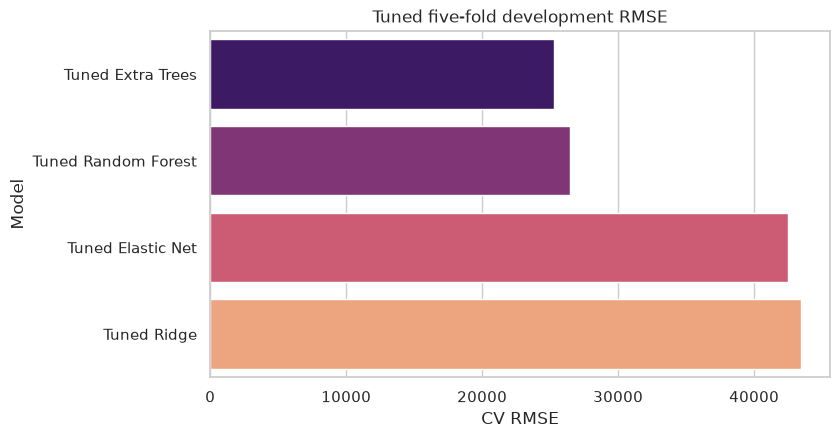

In [12]:
SEARCH_SPACES = {
    "Ridge": (Ridge(), {
        "regressor__model__alpha": loguniform(1e-1, 1e3),
    }),
    "Elastic Net": (ElasticNet(max_iter=20_000, random_state=RANDOM_STATE), {
        "regressor__model__alpha": loguniform(1e-4, 1e1),
        "regressor__model__l1_ratio": uniform(0.05, 0.90),
    }),
    "Extra Trees": (ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=1), {
        "regressor__model__n_estimators": randint(150, 351),
        "regressor__model__max_depth": [None, 10, 16, 24, 32],
        "regressor__model__min_samples_split": randint(2, 16),
        "regressor__model__min_samples_leaf": randint(1, 7),
        "regressor__model__max_features": ["sqrt", .50, .75, 1.0],
    }),
    "Random Forest": (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1), {
        "regressor__model__n_estimators": randint(150, 351),
        "regressor__model__max_depth": [None, 10, 16, 24, 32],
        "regressor__model__min_samples_split": randint(2, 16),
        "regressor__model__min_samples_leaf": randint(1, 7),
        "regressor__model__max_features": ["sqrt", .50, .75, 1.0],
    }),
}

fitted_searches, search_rows = {}, []
for name, (estimator, space) in SEARCH_SPACES.items():
    search = RandomizedSearchCV(
        make_estimator(estimator), param_distributions=space, n_iter=N_SEARCH_ITER,
        scoring=SCORING, refit="rmse", cv=CV, random_state=RANDOM_STATE,
        n_jobs=-1, return_train_score=True, error_score="raise",
    )
    started = perf_counter()
    search.fit(X_train, y_train)
    elapsed = perf_counter() - started
    fitted_searches[name] = search
    best = search.best_index_
    search_rows.append({
        "Model": f"Tuned {name}",
        "CV MAE": -search.cv_results_["mean_test_mae"][best],
        "CV RMSE": -search.best_score_,
        "CV R2": search.cv_results_["mean_test_r2"][best],
        "CV R2 SD": search.cv_results_["std_test_r2"][best],
        "Train R2": search.cv_results_["mean_train_r2"][best],
        "Mean fit time (s)": search.cv_results_["mean_fit_time"][best],
    })
    print(f"{name}: search completed in {elapsed:,.1f}s | best params: {search.best_params_}")

tuned_comparison = pd.DataFrame(search_rows).sort_values("CV RMSE").reset_index(drop=True)
display(tuned_comparison.round({"CV MAE": 0, "CV RMSE": 0, "CV R2": 3, "CV R2 SD": 3, "Train R2": 3, "Mean fit time (s)": 2}))

plt.figure(figsize=(8, 4.5))
sns.barplot(data=tuned_comparison, x="CV RMSE", y="Model", hue="Model", legend=False, palette="magma")
plt.title("Tuned five-fold development RMSE")
plt.show()

## 10. Model comparison, error analysis, and final selection

Default and tuned candidates are compared together on the same development-only metric. The
lowest CV RMSE wins, subject to reasonable stability and train/CV gap — this can be a tuned
model, or a default one if tuning didn't beat it. The test set is used only once, after this
decision, as a final audit rather than another tuning loop.

In [13]:
final_comparison = (pd.concat([comparison, tuned_comparison], ignore_index=True)
                     .sort_values("CV RMSE").reset_index(drop=True))
display(final_comparison.round({"CV MAE": 0, "CV RMSE": 0, "CV R2": 3, "CV R2 SD": 3, "Train R2": 3, "Mean fit time (s)": 2}))

selected_name = final_comparison.loc[0, "Model"]
if selected_name.startswith("Tuned "):
    final_model = fitted_searches[selected_name.removeprefix("Tuned ")].best_estimator_
else:
    final_model = make_estimator(baseline_specs[selected_name]).fit(X_train, y_train)

winner = final_comparison.iloc[0]
print(f"Selected model from development CV: {selected_name}")
print(f"Rationale: lowest CV RMSE ({winner['CV RMSE']:,.0f}) with CV R2 {winner['CV R2']:.3f}, "
      "chosen from both default and tuned candidates; the test data were not consulted.")

,Model,CV MAE,CV RMSE,CV R2,CV R2 SD,Train R2,Mean fit time (s)
0,Tuned Extra Trees,"15,009.000","25,252.000",0.888,0.048,0.997,6.730
1,Extra Trees,"14,979.000","25,456.000",0.885,0.053,1.000,4.370
2,Tuned Random Forest,"15,786.000","26,449.000",0.878,0.044,0.947,3.430
3,Random Forest,"15,759.000","26,537.000",0.876,0.052,0.984,4.210
4,Tuned Elastic Net,"15,079.000","42,480.000",0.357,1.154,0.950,2.980
5,Tuned Ridge,"15,616.000","43,424.000",0.341,1.174,0.953,0.120
6,Ridge,"16,121.000","45,916.000",0.267,1.302,0.911,0.090
7,Elastic Net,"16,251.000","46,790.000",0.227,1.382,0.896,0.170
8,Median baseline,"54,123.000","79,308.000",-0.060,0.015,-0.059,0.090


Selected model from development CV: Tuned Extra Trees
Rationale: lowest CV RMSE (25,252) with CV R2 0.888, chosen from both default and tuned candidates; the test data were not consulted.


## 11. Final test evaluation

The model is fixed. The test results are one-time estimates of generalization to unseen homes,
in original dollars. They must not be used to revise features, preprocessing, or parameters.

,Selected model,Test MAE,Test RMSE,Test R2
0,Tuned Extra Trees,"14,808.000","24,205.000",0.927


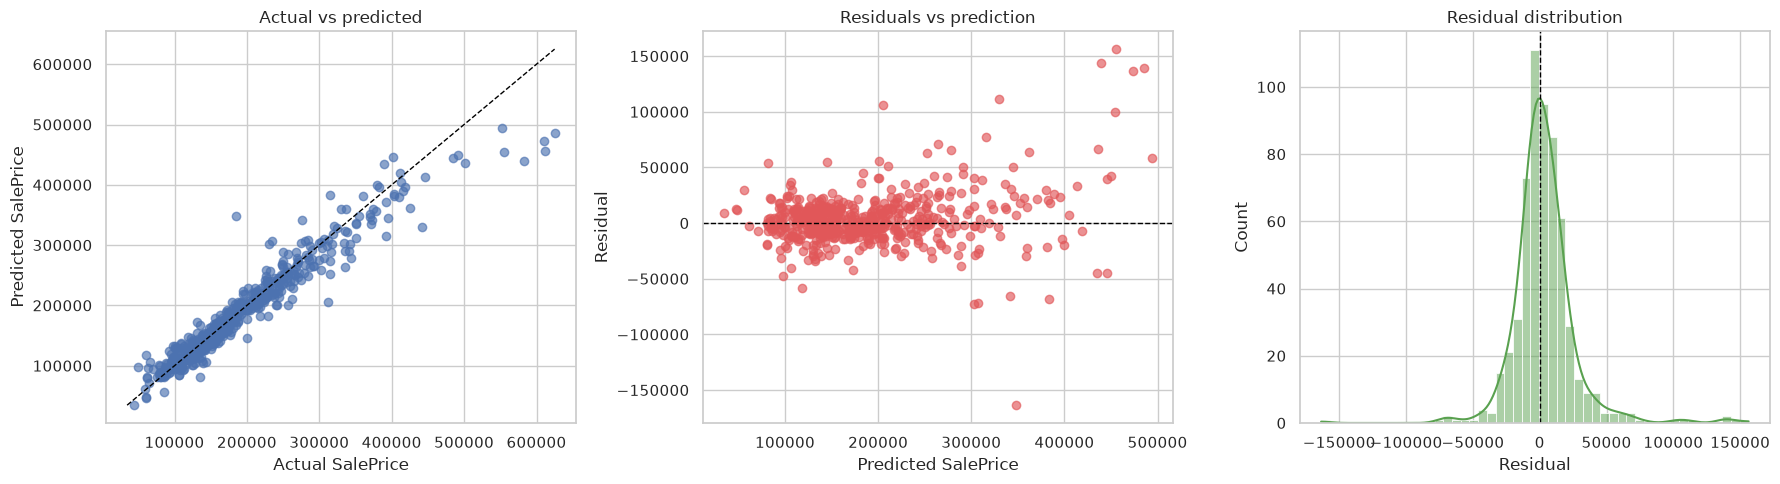

Largest absolute held-out errors: audit examples, not retuning inputs.


,actual,predicted,residual,absolute_error,Overall Qual,Gr Liv Area,Neighborhood
2181,"184,750.000","348,331.063","-163,581.063","163,581.063",10,4676,Edwards
44,"611,657.000","455,393.222","156,263.778","156,263.778",9,2364,NridgHt
433,"582,933.000","439,540.607","143,392.393","143,392.393",9,2822,NridgHt
2445,"625,000.000","485,894.201","139,105.799","139,105.799",10,3627,NoRidge
432,"610,000.000","473,123.811","136,876.189","136,876.189",10,2674,NridgHt
1641,"441,929.000","330,254.423","111,674.577","111,674.577",8,2234,StoneBr
1538,"311,500.000","205,650.837","105,849.163","105,849.163",7,1954,Crawfor
423,"555,000.000","454,813.269","100,186.731","100,186.731",10,2402,NridgHt
1559,"392,500.000","315,340.420","77,159.580","77,159.580",8,1652,Crawfor
944,"230,000.000","302,406.247","-72,406.247","72,406.247",8,1648,Crawfor


In [14]:
test_predictions = final_model.predict(X_test)
test_metrics = pd.DataFrame([{
    "Selected model": selected_name,
    "Test MAE": mean_absolute_error(y_test, test_predictions),
    "Test RMSE": rmse(y_test, test_predictions),
    "Test R2": r2_score(y_test, test_predictions),
}])
display(test_metrics.round({"Test MAE": 0, "Test RMSE": 0, "Test R2": 3}))

errors = pd.DataFrame({"actual": y_test, "predicted": test_predictions}, index=X_test.index)
errors["residual"] = errors["actual"] - errors["predicted"]
errors["absolute_error"] = errors["residual"].abs()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(errors["actual"], errors["predicted"], alpha=.65)
limits = [min(errors[["actual", "predicted"]].min()), max(errors[["actual", "predicted"]].max())]
axes[0].plot(limits, limits, "--", color="black", linewidth=1)
axes[0].set(xlabel="Actual SalePrice", ylabel="Predicted SalePrice", title="Actual vs predicted")
axes[1].scatter(errors["predicted"], errors["residual"], alpha=.65, color="#E15759")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set(xlabel="Predicted SalePrice", ylabel="Residual", title="Residuals vs prediction")
sns.histplot(errors["residual"], kde=True, ax=axes[2], color="#59A14F")
axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].set(xlabel="Residual", title="Residual distribution")
plt.tight_layout()
plt.show()

print("Largest absolute held-out errors: audit examples, not retuning inputs.")
display(errors.join(X_test[["Overall Qual", "Gr Liv Area", "Neighborhood"]]).nlargest(10, "absolute_error"))

,feature,importance
2,numeric__Overall Qual,0.165
51,numeric__TotalSF,0.099
7,numeric__Exter Qual,0.095
30,numeric__Kitchen Qual,0.065
36,numeric__Garage Cars,0.050
52,numeric__TotalBath,0.038
54,numeric__HouseAgeAtSale,0.038
19,numeric__Central Air,0.036
23,numeric__Gr Liv Area,0.035
26,numeric__Full Bath,0.035


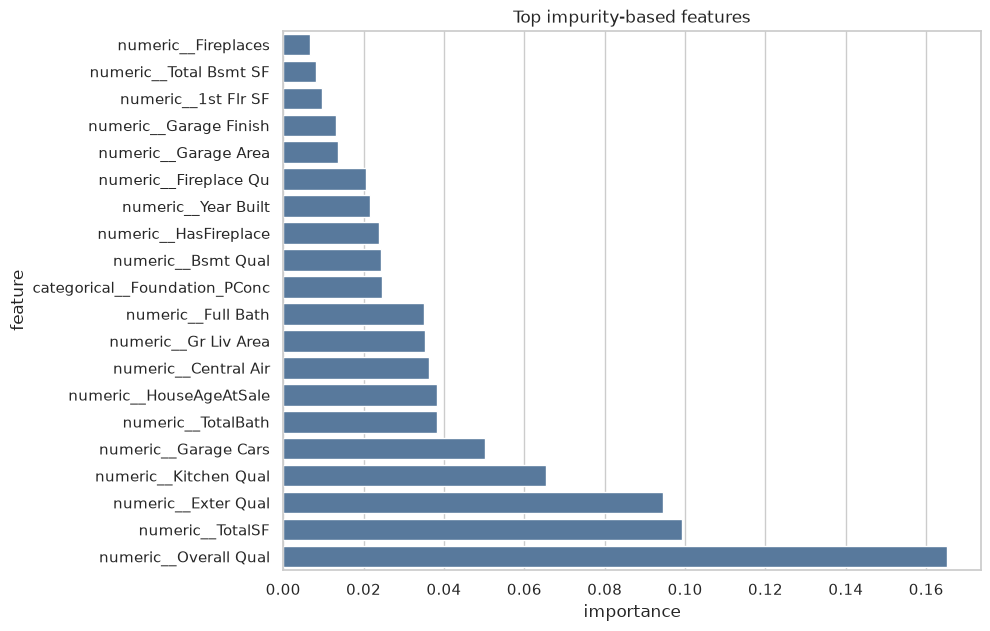

In [15]:
# Tree importance is associative, not causal, and can favor high-cardinality encoded features.
fitted_pipeline = final_model.regressor_
fitted_regressor = fitted_pipeline.named_steps["model"]
if hasattr(fitted_regressor, "feature_importances_"):
    feature_names = fitted_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = (pd.DataFrame({"feature": feature_names, "importance": fitted_regressor.feature_importances_})
                   .sort_values("importance", ascending=False).head(20))
    display(importances.round({"importance": 4}))
    plt.figure(figsize=(9, 7))
    sns.barplot(data=importances.sort_values("importance"), x="importance", y="feature", color="#4C78A8")
    plt.title("Top impurity-based features")
    plt.show()
elif hasattr(fitted_regressor, "coef_"):
    feature_names = fitted_pipeline.named_steps["preprocessor"].get_feature_names_out()
    coefficients = (pd.DataFrame({"feature": feature_names, "coefficient": fitted_regressor.coef_})
                     .assign(abs_coefficient=lambda d: d["coefficient"].abs())
                     .sort_values("abs_coefficient", ascending=False).head(20).drop(columns="abs_coefficient"))
    display(coefficients.round({"coefficient": 4}))
    plt.figure(figsize=(9, 7))
    sns.barplot(data=coefficients.sort_values("coefficient"), x="coefficient", y="feature", color="#4C78A8")
    plt.title("Top standardized-scale linear coefficients")
    plt.show()
else:
    print("Selected model exposes neither feature_importances_ nor coef_.")

**Error interpretation.** The residual plot checks for systematic bias across fitted prices and
the histogram checks centering/spread. Largest-error homes are diagnostic examples, not a
reason to delete test rows. Importance/coefficients are descriptive rather than causal and
should be paired with domain knowledge.

## 12. Complete production pipeline

`final_model` contains the full feature engineering, imputation, encoding, scaling, and
regression workflow. It is trained only on development data and accepts raw input rows with the
original Ames schema. Keep `ames_features.py` next to `model.pkl` — that's the only extra file
a fresh process needs to load and use it.

In [16]:
MODEL_PATH = Path("model.pkl")
joblib.dump(final_model, MODEL_PATH)
reloaded = joblib.load(MODEL_PATH)
example = X_test.iloc[[0]].copy()
first_prediction = float(final_model.predict(example)[0])
reloaded_prediction = float(reloaded.predict(example)[0])
if not np.isclose(first_prediction, reloaded_prediction):
    raise RuntimeError("Reloaded model prediction differs from in-memory pipeline.")
print(f"Saved complete raw-input pipeline to {MODEL_PATH.resolve()}")
print(f"Serialization check prediction: {reloaded_prediction:,.0f} USD")
print("The reloaded pipeline performs all transformations internally; ames_features.py must ship alongside model.pkl.")

Saved complete raw-input pipeline to /home/trozan24/Downloads/Coding/projects/Ames-House-Prediction/model.pkl
Serialization check prediction: 155,761 USD
The reloaded pipeline performs all transformations internally; ames_features.py must ship alongside model.pkl.
